<a href="https://colab.research.google.com/github/Ami14123/business-analytics-project/blob/main/Data_Analysis_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In order to understand what my model is approximating, need to draw the joint probability table first
***The joint table becomes huge if you use many variables

==> check my understanding: Can I express my purchase intention problem as a joint probability distribution?





# Import library:


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.metrics import confusion_matrix, roc_curve, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from xgboost import plot_importance
import re # Import the re module for regular expressions
from sklearn.metrics import confusion_matrix, roc_curve, RocCurveDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, RocCurveDisplay
import shap



# Load dataset


In [ ]:

# --- Load raw datasets
student_info = pd.read_csv("studentInfo.csv")
student_registration = pd.read_csv("studentRegistration.csv")
student_vle = pd.read_csv("studentVle.csv", on_bad_lines='skip', engine='python')
vle = pd.read_csv("vle.csv")
assessments = pd.read_csv("assessments.csv")
student_assessment = pd.read_csv("studentAssessment.csv")
courses = pd.read_csv("courses.csv")

# Data cleaning

In [ ]:
# --- Apply cleaning steps for missing values
vle['week_from'] = vle['week_from'].fillna(-1)  # -1 means 'always available'
vle['week_to'] = vle['week_to'].fillna(-1)

assessments['date'] = assessments['date'].fillna(assessments['date'].median())

student_assessment['score'] = student_assessment['score'].fillna(0)

student_info['imd_band'] = student_info['imd_band'].fillna('Unknown')

student_registration['date_registration'] = student_registration['date_registration'].fillna(
    student_registration['date_registration'].median()
)

# Fill any remaining numerical missing values with 0 for student_vle and courses
# Note: student_vle should be handled more specifically later for duplicates, this is a general fill.
student_vle = student_vle.fillna(0)
courses = courses.fillna(0)

# --- Save cleaned files
student_info.to_csv("clean_studentInfo.csv", index=False)
student_registration.to_csv("clean_studentRegistration.csv", index=False)
vle.to_csv("clean_vle.csv", index=False)
assessments.to_csv("clean_assessments.csv", index=False)
student_assessment.to_csv("clean_studentAssessment.csv", index=False)
student_vle.to_csv("clean_studentVle.csv", index=False) # This will be processed further
courses.to_csv("clean_courses.csv", index=False)
print("Cleaned datasets saved with 'clean_' prefix.")

# --- Process studentVle and calculate engagement features (Steps 5-9)
# Load the clean_studentVle.csv (though it's already in memory as student_vle)
# student_vle = pd.read_csv("clean_studentVle.csv") # Not strictly needed as it's already in memory

# Remove duplicate entries in studentVle by grouping and summing clicks
student_vle = (
    student_vle
    .groupby(['code_module', 'code_presentation', 'id_student', 'id_site', 'date'], dropna=False, as_index=False)
    .agg({'sum_click': 'sum'})
)
student_vle.to_csv("cleaned_noduplicates_studentVle.csv", index=False)
print("cleaned_noduplicates_studentVle.csv saved.")

# Calculate engagement features
interaction_summary = (
    student_vle.groupby(['code_module', 'code_presentation','id_student'])
    .agg(
        total_clicks=('sum_click', 'sum'),
        active_days=('date', 'nunique')
    )
    .reset_index()
)

interaction_summary['interaction_frequency'] = (
    interaction_summary['total_clicks'] / interaction_summary['active_days']
).round(2)

interaction_summary.to_csv("interaction_summary.csv", index=False)
print("interaction_summary.csv saved.")

display(interaction_summary.head())

Cleaned datasets saved with 'clean_' prefix.
cleaned_noduplicates_studentVle.csv saved.
interaction_summary.csv saved.


,code_module,code_presentation,id_student,total_clicks,active_days,interaction_frequency
0,AAA,2013J,11391.0,934.0,40,23.35
1,AAA,2013J,28400.0,1435.0,80,17.94
2,AAA,2013J,30268.0,281.0,12,23.42
3,AAA,2013J,31604.0,2158.0,123,17.54
4,AAA,2013J,32885.0,1034.0,70,14.77


# Feature engineering

In [ ]:

# Load the saved cleaned dataframes
student_info = pd.read_csv("clean_studentInfo.csv")
student_registration = pd.read_csv("clean_studentRegistration.csv")
# student_assessment = pd.read_csv("clean_studentAssessment.csv") # Will be loaded later for assessment features
# assessments = pd.read_csv("clean_assessments.csv") # Will be loaded later for assessment features
interaction_summary = pd.read_csv("interaction_summary.csv")

# Merge studentInfo and studentRegistration to create the base master DataFrame
merged_df = pd.merge(student_info, student_registration, on=['id_student', 'code_module', 'code_presentation'], how='left')

# Merge interaction_summary into the master DataFrame
merged_df = pd.merge(merged_df, interaction_summary, on=['id_student', 'code_module', 'code_presentation'], how='left')

print("Master DataFrame created and merged with engagement features:")
display(merged_df.head())
print(merged_df.columns)

Master DataFrame created and merged with engagement features:


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration,total_clicks,active_days,interaction_frequency
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,-159.0,NaN,934.0,40.0,23.35
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,-53.0,NaN,1435.0,80.0,17.94
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,-92.0,12.0,281.0,12.0,23.42
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,-52.0,NaN,2158.0,123.0,17.54
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,-176.0,NaN,1034.0,70.0,14.77


Index(['code_module', 'code_presentation', 'id_student', 'gender', 'region',
       'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts',
       'studied_credits', 'disability', 'final_result', 'date_registration',
       'date_unregistration', 'total_clicks', 'active_days',
       'interaction_frequency'],
      dtype='object')


In [ ]:


# Load the cleaned assessment dataframes
student_assessment = pd.read_csv("clean_studentAssessment.csv")
assessments = pd.read_csv("clean_assessments.csv")

# Merge studentAssessment and assessments to combine assessment details with student performance
assessments_merged_df = pd.merge(student_assessment, assessments, on='id_assessment', how='left')

# Calculate average score per student for each course presentation
student_avg_score = assessments_merged_df.groupby(['id_student', 'code_module', 'code_presentation'])['score'].mean().reset_index()
student_avg_score.rename(columns={'score': 'average_score'}, inplace=True)

# Calculate the average submission delay (date_submitted - date) per student for each course presentation
# Ensure 'date' and 'date_submitted' are treated as numerical days
assessments_merged_df['submission_delay'] = assessments_merged_df['date_submitted'] - assessments_merged_df['date']
student_avg_submission_delay = assessments_merged_df.groupby(['id_student', 'code_module', 'code_presentation'])['submission_delay'].mean().reset_index()
student_avg_submission_delay.rename(columns={'submission_delay': 'average_submission_delay'}, inplace=True)

# Merge assessment features with the main merged_df
merged_df = pd.merge(merged_df, student_avg_score, on=['id_student', 'code_module', 'code_presentation'], how='left')
merged_df = pd.merge(merged_df, student_avg_submission_delay, on=['id_student', 'code_module', 'code_presentation'], how='left')

print("Master DataFrame updated with Assessment Features:")
display(merged_df.head())

Master DataFrame updated with Assessment Features:


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration,total_clicks,active_days,interaction_frequency,average_score,average_submission_delay
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,-159.0,NaN,934.0,40.0,23.35,82.0,-1.8
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,-53.0,NaN,1435.0,80.0,17.94,66.4,0.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,-92.0,12.0,281.0,12.0,23.42,NaN,NaN
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,-52.0,NaN,2158.0,123.0,17.54,76.0,-2.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,-176.0,NaN,1034.0,70.0,14.77,54.4,11.4


#### create drop_out column

In [ ]:

# --- Preprocessing Master DataFrame for Modeling ---

# Reload the saved cleaned dataframes and re-merge to ensure 'merged_df' is in the expected state
student_info = pd.read_csv("clean_studentInfo.csv")
student_registration = pd.read_csv("clean_studentRegistration.csv")
interaction_summary = pd.read_csv("interaction_summary.csv")

merged_df = pd.merge(student_info, student_registration, on=['id_student', 'code_module', 'code_presentation'], how='left')
merged_df = pd.merge(merged_df, interaction_summary, on=['id_student', 'code_module', 'code_presentation'], how='left')

# Load and merge assessment features
student_assessment = pd.read_csv("clean_studentAssessment.csv")
assessments = pd.read_csv("clean_assessments.csv")
assessments_merged_df = pd.merge(student_assessment, assessments, on='id_assessment', how='left')

student_avg_score = assessments_merged_df.groupby(['id_student', 'code_module', 'code_presentation'])['score'].mean().reset_index()
student_avg_score.rename(columns={'score': 'average_score'}, inplace=True)

assessments_merged_df['submission_delay'] = assessments_merged_df['date_submitted'] - assessments_merged_df['date']
student_avg_submission_delay = assessments_merged_df.groupby(['id_student', 'code_module', 'code_presentation'])['submission_delay'].mean().reset_index()
student_avg_submission_delay.rename(columns={'submission_delay': 'average_submission_delay'}, inplace=True)

merged_df = pd.merge(merged_df, student_avg_score, on=['id_student', 'code_module', 'code_presentation'], how='left')
merged_df = pd.merge(merged_df, student_avg_submission_delay, on=['id_student', 'code_module', 'code_presentation'], how='left')


# 1. Handle missing values in newly merged columns
# Fill NaN engagement features with 0, assuming no activity if data is missing
merged_df['total_clicks'] = merged_df['total_clicks'].fillna(0)
merged_df['active_days'] = merged_df['active_days'].fillna(0)
merged_df['interaction_frequency'] = merged_df['interaction_frequency'].fillna(0)

# Fill NaN assessment features with their respective medians, as 'no assessment taken' might skew the average heavily if filled with 0
# For students who didn't take any assessment, average_score would be NaN. Filling with 0 might be misleading.
# Let's fill with the overall median score/delay. Alternatively, these could be handled by a 'has_taken_assessment' flag.
# For now, using median to represent a 'typical' value for those who don't have records.
merged_df['average_score'] = merged_df['average_score'].fillna(merged_df['average_score'].median())
merged_df['average_submission_delay'] = merged_df['average_submission_delay'].fillna(merged_df['average_submission_delay'].median())

# Create 'dropped_out' column based on 'final_result'
# Assuming 'Withdrawn' indicates dropout, and other results (Pass, Fail) indicate non-dropout.
merged_df['dropped_out'] = (merged_df['final_result'] == 'Withdrawn').astype(int)

# 2. One-hot encode categorical features
categorical_cols = [
    'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability'
]
merged_df = pd.get_dummies(merged_df, columns=categorical_cols, drop_first=False)

# 3. Ensure the 'dropout' target variable is correctly named and set
# The 'dropped_out' column was created earlier, we will rename it to 'dropout' for consistency
merged_df.rename(columns={'dropped_out': 'dropout'}, inplace=True)

# Display the first few rows and the columns to verify preprocessing
print("Master DataFrame after preprocessing (first 5 rows and columns):")
display(merged_df.head())
print("\nShape of the preprocessed DataFrame:", merged_df.shape)
print("\nMissing values after preprocessing:")
print(merged_df.isnull().sum()[merged_df.isnull().sum() > 0])


Master DataFrame after preprocessing (first 5 rows and columns):


,code_module,code_presentation,id_student,num_of_prev_attempts,studied_credits,final_result,date_registration,date_unregistration,total_clicks,active_days,...,imd_band_60-70%,imd_band_70-80%,imd_band_80-90%,imd_band_90-100%,imd_band_Unknown,age_band_0-35,age_band_35-55,age_band_55<=,disability_N,disability_Y
0,AAA,2013J,11391,0,240,Pass,-159.0,NaN,934.0,40.0,...,False,False,False,True,False,False,False,True,True,False
1,AAA,2013J,28400,0,60,Pass,-53.0,NaN,1435.0,80.0,...,False,False,False,False,False,False,True,False,True,False
2,AAA,2013J,30268,0,60,Withdrawn,-92.0,12.0,281.0,12.0,...,False,False,False,False,False,False,True,False,False,True
3,AAA,2013J,31604,0,60,Pass,-52.0,NaN,2158.0,123.0,...,False,False,False,False,False,False,True,False,True,False
4,AAA,2013J,32885,0,60,Pass,-176.0,NaN,1034.0,70.0,...,False,False,False,False,False,True,False,False,True,False



Shape of the preprocessed DataFrame: (32593, 50)

Missing values after preprocessing:
date_unregistration    22521
dtype: int64


In [ ]:
print(merged_df.head())

  code_module code_presentation  id_student  num_of_prev_attempts  \
0         AAA             2013J       11391                     0   
1         AAA             2013J       28400                     0   
2         AAA             2013J       30268                     0   
3         AAA             2013J       31604                     0   
4         AAA             2013J       32885                     0   

   studied_credits final_result  date_registration  date_unregistration  \
0              240         Pass             -159.0                  NaN   
1               60         Pass              -53.0                  NaN   
2               60    Withdrawn              -92.0                 12.0   
3               60         Pass              -52.0                  NaN   
4               60         Pass             -176.0                  NaN   

   total_clicks  active_days  ...  imd_band_60-70%  imd_band_70-80%  \
0         934.0         40.0  ...            False            F

/tmp/ipython-input-3822239661.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dropout_counts.index, y=dropout_counts.values, palette='viridis')


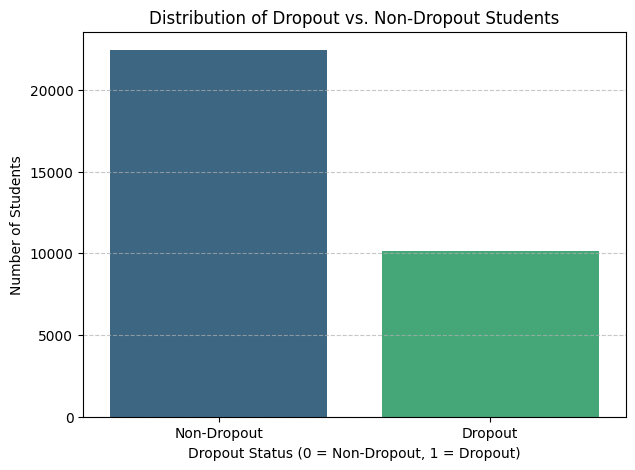

Number of non-dropout students: 22437
Number of dropout students: 10156


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

dropout_counts = merged_df['dropout'].value_counts().sort_index()

plt.figure(figsize=(7, 5))
sns.barplot(x=dropout_counts.index, y=dropout_counts.values, palette='viridis')
plt.title('Distribution of Dropout vs. Non-Dropout Students')
plt.xlabel('Dropout Status (0 = Non-Dropout, 1 = Dropout)')
plt.ylabel('Number of Students')
plt.xticks(ticks=[0, 1], labels=['Non-Dropout', 'Dropout'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Number of non-dropout students:", dropout_counts.get(0, 0))
print("Number of dropout students:", dropout_counts.get(1, 0))

# Train Logistic model:


In [ ]:


# Define target variable
y_dropout = merged_df['dropout']

# Dynamically get one-hot encoded categorical feature columns
categorical_prefixes = ['gender_', 'region_', 'highest_education_', 'imd_band_', 'age_band_', 'disability_']
one_hot_cols = [col for col in merged_df.columns if any(col.startswith(prefix) for prefix in categorical_prefixes)]

# Define numerical and engineered features
numerical_and_engineered_cols = [
    'num_of_prev_attempts',
    'studied_credits',
    'total_clicks',
    'active_days',
    'interaction_frequency',
    'average_score',
    'average_submission_delay'
]

# Combine all feature columns
feature_cols = numerical_and_engineered_cols + one_hot_cols

# Define features (X) for dropout prediction
X_dropout_selected = merged_df[feature_cols]

# Split data into training and testing sets
X_train_dropout, X_test_dropout, y_train_dropout, y_test_dropout = train_test_split(
    X_dropout_selected, y_dropout, test_size=0.2, random_state=42, stratify=y_dropout
)

# Initialize and train Logistic Regression model
# Increased max_iter to address ConvergenceWarning
log_reg_model = LogisticRegression(max_iter=5000, random_state=42)
log_reg_model.fit(X_train_dropout, y_train_dropout)

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test_dropout)
y_pred_proba_log_reg = log_reg_model.predict_proba(X_test_dropout)[:, 1]

# Evaluate the model
print("Logistic Regression Model Evaluation (Dropout Prediction with Selected Features):")
print(f"Accuracy: {accuracy_score(y_test_dropout, y_pred_log_reg)}")
print(f"ROC AUC Score: {roc_auc_score(y_test_dropout, y_pred_proba_log_reg)}")
print("Classification Report:")
print(classification_report(y_test_dropout, y_pred_log_reg))

Logistic Regression Model Evaluation (Dropout Prediction with Selected Features):
Accuracy: 0.7039423224420923
ROC AUC Score: 0.704725759199432
Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.95      0.81      4488
           1       0.59      0.17      0.26      2031

    accuracy                           0.70      6519
   macro avg       0.65      0.56      0.54      6519
weighted avg       0.68      0.70      0.64      6519



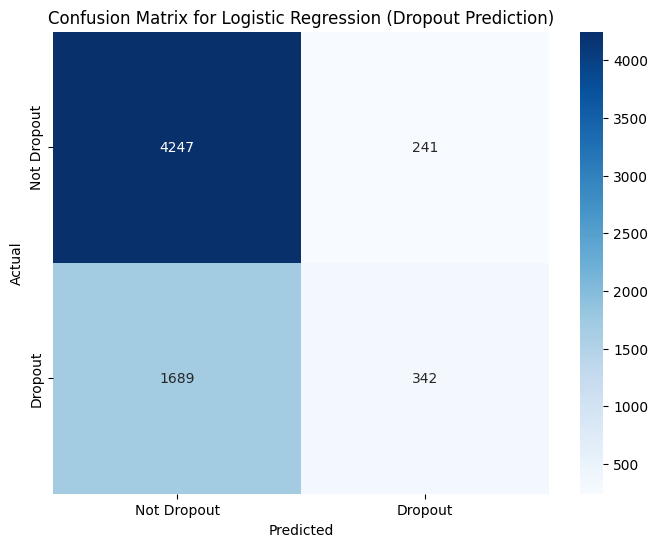

<Figure size 800x600 with 0 Axes>

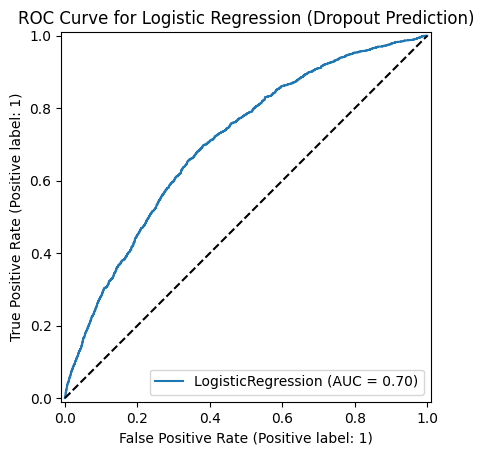

In [ ]:


# Plot Confusion Matrix
cm = confusion_matrix(y_test_dropout, y_pred_log_reg)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Dropout', 'Dropout'], yticklabels=['Not Dropout', 'Dropout'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Logistic Regression (Dropout Prediction)')
plt.show()

# Plot ROC Curve
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(log_reg_model, X_test_dropout, y_test_dropout)
plt.title('ROC Curve for Logistic Regression (Dropout Prediction)')
plt.plot([0, 1], [0, 1], 'k--') # Plot random chance line
plt.show()

# Train XG Boost model

In [ ]:


# Define target variable
y_dropout = merged_df['dropout']

# Dynamically get one-hot encoded categorical feature columns
categorical_prefixes = ['gender_', 'region_', 'highest_education_', 'imd_band_', 'age_band_', 'disability_']
one_hot_cols = [col for col in merged_df.columns if any(col.startswith(prefix) for prefix in categorical_prefixes)]

# Define numerical and engineered features
numerical_and_engineered_cols = [
    'num_of_prev_attempts',
    'studied_credits',
    'total_clicks',
    'active_days',
    'interaction_frequency',
    'average_score',
    'average_submission_delay'
]

# Combine all feature columns
feature_cols = numerical_and_engineered_cols + one_hot_cols

# Define features (X) for dropout prediction
X_dropout_selected = merged_df[feature_cols]

# Sanitize column names for XGBoost
# Replace any character that is not alphanumeric or an underscore with an underscore
X_dropout_selected.columns = X_dropout_selected.columns.str.replace(r'[^A-Za-z0-9_]+', '_', regex=True)
# Replace multiple underscores with a single underscore
X_dropout_selected.columns = X_dropout_selected.columns.str.replace(r'_{2,}', '_', regex=True)
# Remove leading/trailing underscores
X_dropout_selected.columns = X_dropout_selected.columns.str.strip('_')

# Split data into training and testing sets
X_train_dropout, X_test_dropout, y_train_dropout, y_test_dropout = train_test_split(
    X_dropout_selected, y_dropout, test_size=0.2, random_state=42, stratify=y_dropout
)

# Initialize and train XGBoost model
xgb_model = XGBClassifier(
    n_estimators=300,        # number of trees
    max_depth=4,            # how deep each tree can go
    learning_rate=0.1,      # step size shrinkage
    subsample=0.8,          # row sampling
    colsample_bytree=0.8,   # column sampling
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train_dropout, y_train_dropout)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test_dropout)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_dropout)[:, 1]

# Evaluate the model
print("XGBoost Model Evaluation (Dropout Prediction with Selected Features):")
print(f"Accuracy: {accuracy_score(y_test_dropout, y_pred_xgb)}")
print(f"ROC AUC Score: {roc_auc_score(y_test_dropout, y_pred_proba_xgb)}")
print("Classification Report:")
print(classification_report(y_test_dropout, y_pred_xgb))

XGBoost Model Evaluation (Dropout Prediction with Selected Features):
Accuracy: 0.8326430434115661
ROC AUC Score: 0.8833232511929618
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.92      0.88      4488
           1       0.78      0.65      0.71      2031

    accuracy                           0.83      6519
   macro avg       0.82      0.78      0.79      6519
weighted avg       0.83      0.83      0.83      6519



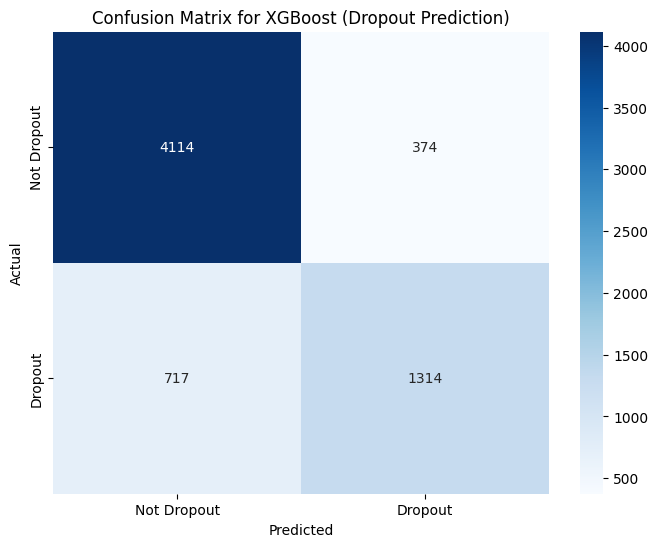

<Figure size 800x600 with 0 Axes>

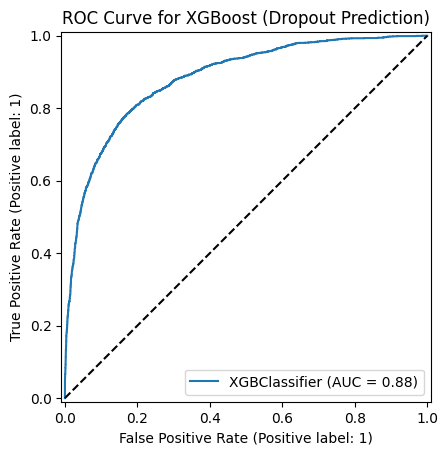

In [ ]:
from sklearn.metrics import confusion_matrix, roc_curve, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFUSION MATRIX ---
cm = confusion_matrix(y_test_dropout, y_pred_xgb)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Not Dropout', 'Dropout'],
    yticklabels=['Not Dropout', 'Dropout']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for XGBoost (Dropout Prediction)')
plt.show()

# --- ROC CURVE ---
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(xgb_model, X_test_dropout, y_test_dropout)
plt.title('ROC Curve for XGBoost (Dropout Prediction)')
plt.plot([0, 1], [0, 1], 'k--')  # Random baseline
plt.show()


/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


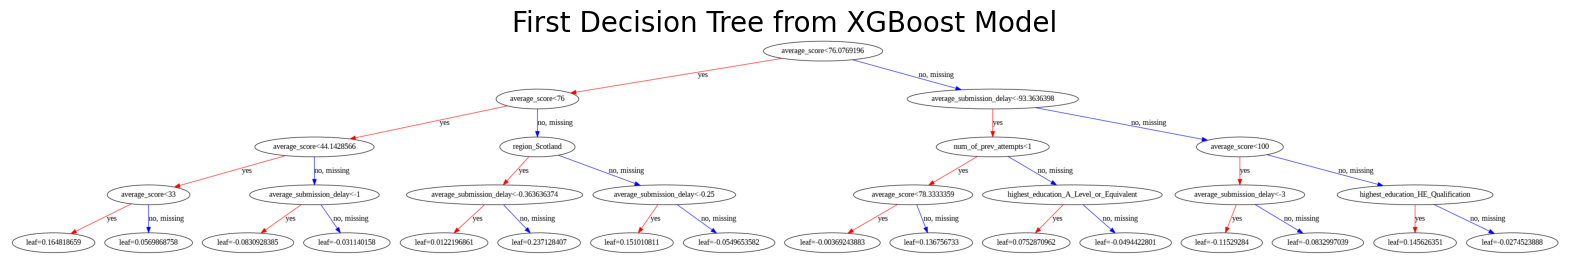

In [ ]:
import matplotlib.pyplot as plt
from xgboost import plot_tree

# To visualize a single tree from the XGBoost model
# We'll plot the first tree (index=0) as an example.
# You can choose any tree index up to n_estimators-1.

fig, ax = plt.subplots(figsize=(20, 20))  # Adjust figure size for better readability
plot_tree(xgb_model, num_trees=0, ax=ax)
plt.title('First Decision Tree from XGBoost Model', fontsize=20)
plt.show()


# Train random forest model

In [ ]:


# Initialize Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=300,      # number of trees
    max_depth=None,       # let trees expand fully (you can tune this)
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1             # use all CPU cores
)

# Train the model
rf_model.fit(X_train_dropout, y_train_dropout)

# Predictions
y_pred_rf = rf_model.predict(X_test_dropout)
y_pred_proba_rf = rf_model.predict_proba(X_test_dropout)[:, 1]

# Evaluation
print("Random Forest Model Evaluation (Dropout Prediction):")
print(f"Accuracy: {accuracy_score(y_test_dropout, y_pred_rf)}")
print(f"ROC AUC Score: {roc_auc_score(y_test_dropout, y_pred_proba_rf)}")
print("Classification Report:")
print(classification_report(y_test_dropout, y_pred_rf))


Random Forest Model Evaluation (Dropout Prediction):
Accuracy: 0.818530449455438
ROC AUC Score: 0.858209506218673
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.93      0.88      4488
           1       0.79      0.57      0.66      2031

    accuracy                           0.82      6519
   macro avg       0.81      0.75      0.77      6519
weighted avg       0.81      0.82      0.81      6519



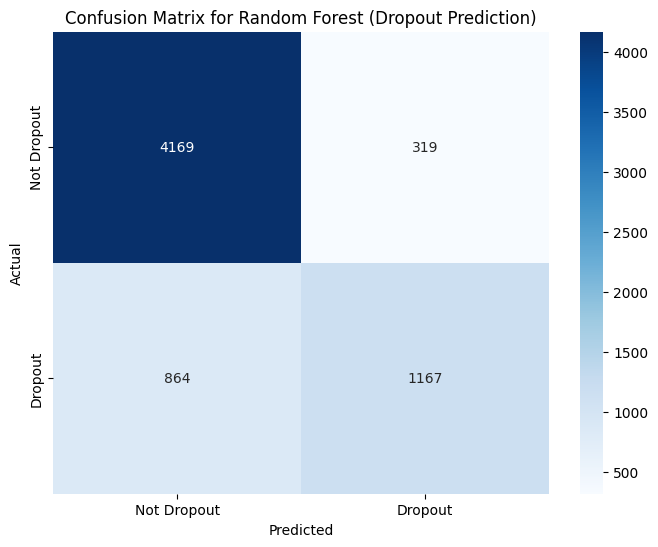

<Figure size 800x600 with 0 Axes>

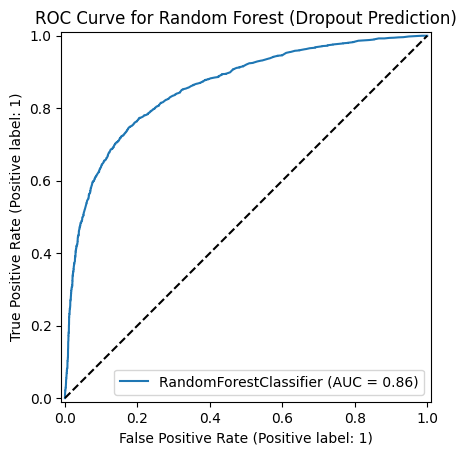

In [ ]:


# --- CONFUSION MATRIX ---
cm_rf = confusion_matrix(y_test_dropout, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_rf, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Not Dropout', 'Dropout'],
    yticklabels=['Not Dropout', 'Dropout']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Random Forest (Dropout Prediction)')
plt.show()

# --- ROC CURVE ---
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(rf_model, X_test_dropout, y_test_dropout)
plt.title('ROC Curve for Random Forest (Dropout Prediction)')
plt.plot([0, 1], [0, 1], 'k--')  # Random baseline
plt.show()


# Model selection:



###(Mai's part)Metrics selection:
| **Metric**                  | **What it Measures**                                 | **Best Used When**                                             | **Weakness**                          | **Meaning in the Context of Dropout Prediction**                                                                                                                                               |
| --------------------------- | ---------------------------------------------------- | -------------------------------------------------------------- | ------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Accuracy**                | Overall correctness: ((TP + TN) / \{Total})      | • Classes are balanced<br>• FP and FN have similar cost        | Misleading when one class is majority | Most students are **not** dropouts → accuracy stays high even if the model misses real dropouts (FN). Not suitable because detecting the minority class is more important.                     |
| **Precision (Dropout = 1)** | How often predicted dropout is correct: (TP/(TP+FP)) | • When false alarms (FP) must be minimized                     | Ignores FN (missed dropouts)          | High precision = fewer false alarms. But here false alarms are acceptable. Precision is **not** the priority because the goal is not to avoid warnings—it is to **catch real dropouts**.       |
| **Recall (Dropout = 1)**    | Ability to catch real dropouts: (TP/(TP+FN))         | • Missing positives is costly<br>• Minority class is important | Can increase false alarms (FP)        | **Most important metric.** Missing a dropout (FN) means the university loses the chance to support that student. High recall means the model identifies more at-risk students early.           |
| **F1-score (Dropout = 1)**  | Balanced mean of precision and recall                | • Classes are imbalanced<br>• Need balance between FP & FN     | Slightly harder to interpret          | **Second most important metric.** Provides a balanced measure of how well the model identifies true dropouts while keeping unnecessary alerts manageable. Ideal for minority-class evaluation. |


=>purpose: to predict dropout =>  go with the model that have highest recall and F1-score


## ( Matt's ) Model selection based on selected metrics
XGBoost has highest recall (0.66) and F1-score = 0.72
XGBoost = Best overall model

### 1. XGBoost = Highest Accuracy, ROC AUC, and F1-score (Dropout class)

Tied for best Recall (most important metric)

Most balanced model for catching dropouts while keeping false positives reasonable
###2. Logistic Regression = Best simple model

Tied for highest Recall (0.66)

Lower accuracy and ROC AUC compared to XGBoost

Best if interpretability is required

###3. Random Forest = Good precision, weak recall

Best Precision (0.79) → least false alarms

But lowest Recall (0.60) → misses many real dropouts

Not ideal for student-risk detection

##Business application
For an early-warning dropout detection system, recall and F1-score are the key metrics, because the university wants to identify as many at-risk students as possible.
# XGBoost provides the strongest performance on these critical metrics and is the recommended model for deployment.

## ( Matt's part) 2nd GOAL : Identify predictors of dropout

<Figure size 1600x1800 with 0 Axes>

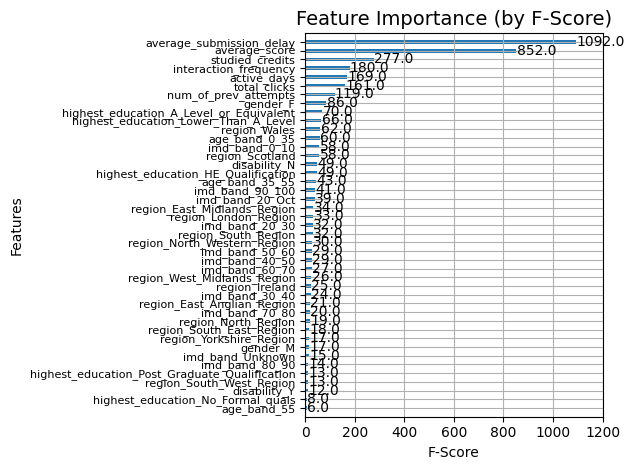

In [ ]:
plt.figure(figsize=(16, 18))
ax = plot_importance(xgb_model, importance_type='weight', xlabel='F-Score', height=0.4)
ax.set_title("Feature Importance (by F-Score)", fontsize=14)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()



=> This plot answers the question:

“Which features does the model use most often to split the data?”

A higher F-score ===  the feature was used more frequently across all trees.

Insights:

average_submission_delay (top feature)
→ Used in 1,020 splits → extremely important

average_score (744 splits)
→ Strong predictor of dropout behavior

total_clicks, active_days, interaction_frequency, studied_credits
→ These engagement features strongly influence the prediction

=> it shows that performance measures while strongly influence the prediction, but aren't best indicators of dropout

### plot feature importance for "recall" metrics

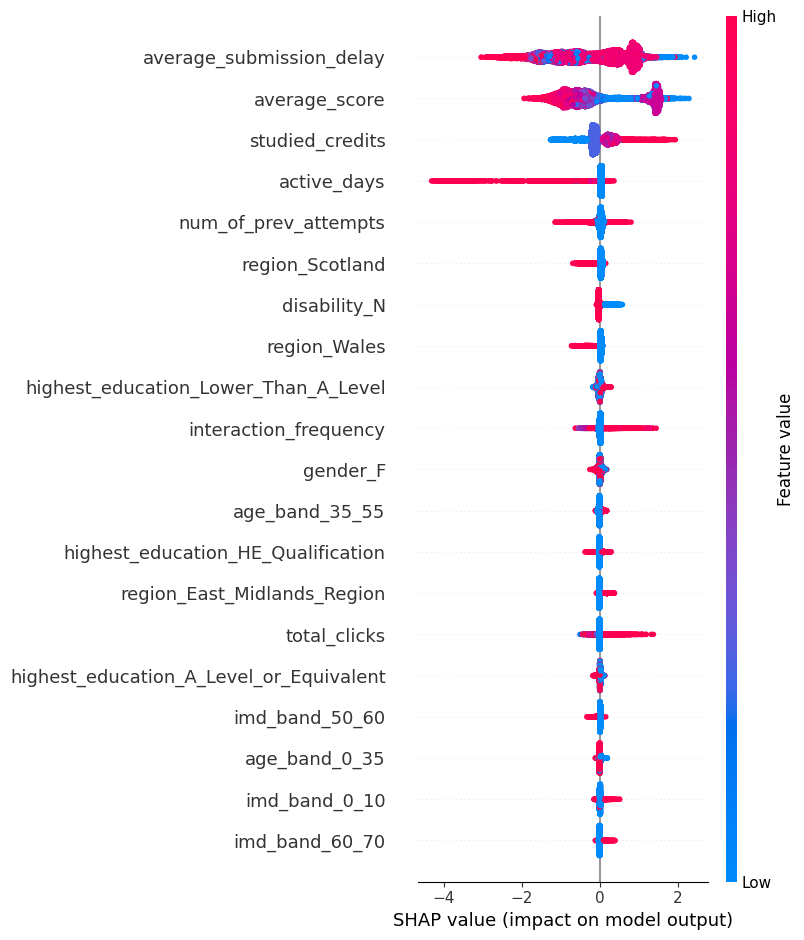

In [ ]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_train_dropout)

shap.summary_plot(shap_values, X_train_dropout)


=> SHAP answers:

“How does each feature PUSH the prediction toward dropout or non-dropout?”
“Do high values or low values increase dropout risk?”

=> How to read the SHAP Summary Plot

*Each feature has many dots (one for each student).
Color = feature value

Pink = High values

Blue = Low values

*SHAP value on x-axis =

Positive → pushes prediction toward dropout (1)

Negative → pushes prediction away from dropout (toward 0)

##Plot Intepretation:
1. average_submission_delay

High (pink) → strongly pushes toward dropout → students who submit late are high-risk.

Low (blue) → pushes toward non-dropout.

->
Students who are consistently late with submissions are much more likely to drop out.

2. average_score

Low scores (blue) → push toward dropout

High scores (pink) → push toward retention

->
Academic performance is a strong predictor: struggling students drop out more.

3. active_days

Low active days (blue) → push toward dropout

High active days (pink) → push toward retention

->
Students who rarely log in are at high risk.

4. studied_credits

Lower studied credits → small push toward dropout

Higher credits → push toward staying

->
Students taking a heavier load are more committed and less likely to drop.

5. interaction_frequency

Low interactions → push toward dropout

High interactions → push toward non-dropout

->
Students who interact with the learning platform more often are more engaged.

6. total_clicks

Low clicks → risk of dropout

High clicks → more likely to stay

->
Total digital engagement remains a key behavioral signal.

7. num_of_prev_attempts

Mixed effect:

Some high values push toward dropout (students repeating may be at-risk)

Some push toward passing

->
Complicated pattern — repeated attempts can show perseverance or failure.

=> Demographics (gender, region, disability, age_band)

Very small SHAP value range → weak predictors

Engagement + performance features dominate

##=> future work Train with Bayesian Network model




| Model                       | Accuracy | ROC AUC | Precision (Dropout) | Recall (Dropout) | F1-Score (Dropout) |
| :---------------------------- | :------- | :------ | :------------------ | :--------------- | :----------------- |
| **XGBoost**                   | **0.833**| **0.888**| **0.78**            | **0.65**         | **0.71**           |
| Random Forest                 | 0.818    | 0.863   | 0.78                | 0.58             | 0.66               |
| Logistic Regression           | 0.710    | 0.719   | 0.61                | 0.19             | 0.29               |
| Dummy Classifier (Stratified) | 0.566    | 0.492   | 0.30                | 0.30             | 0.30               |





In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize DummyClassifier with 'stratified' strategy
# This strategy generates predictions by respecting the training set's class distribution.
dummy_clf = DummyClassifier(strategy='stratified', random_state=42)

# Train the dummy classifier
dummy_clf.fit(X_train_dropout, y_train_dropout)
print(dummy_clf)

# Make predictions on the test set
y_pred_dummy = dummy_clf.predict(X_test_dropout)
y_pred_proba_dummy = dummy_clf.predict_proba(X_test_dropout)[:, 1]

# Evaluate the model
print("Dummy Classifier (Stratified) Baseline Evaluation:")
print(f"Accuracy: {accuracy_score(y_test_dropout, y_pred_dummy)}")
print(f"ROC AUC Score: {roc_auc_score(y_test_dropout, y_pred_proba_dummy)}")
print("Classification Report:")
print(classification_report(y_test_dropout, y_pred_dummy))


DummyClassifier(random_state=42, strategy='stratified')
Dummy Classifier (Stratified) Baseline Evaluation:
Accuracy: 0.5658843380886639
ROC AUC Score: 0.4918504161433608
Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.69      0.69      4488
           1       0.30      0.30      0.30      2031

    accuracy                           0.57      6519
   macro avg       0.49      0.49      0.49      6519
weighted avg       0.56      0.57      0.56      6519



In [ ]:
print("Class distribution in y_train_dropout:")
print(y_train_dropout.value_counts(normalize=True))

Class distribution in y_train_dropout:
dropout
0    0.688387
1    0.311613
Name: proportion, dtype: float64


In [ ]:
print("Predicted class distribution by Dummy Classifier (Stratified) on test set:")
print(pd.Series(y_pred_dummy).value_counts(normalize=True))

Predicted class distribution by Dummy Classifier (Stratified) on test set:
0    0.693358
1    0.306642
Name: proportion, dtype: float64


In [ ]:
print("Actual class distribution in y_test_dropout:")
print(y_test_dropout.value_counts(normalize=True))

Actual class distribution in y_test_dropout:
dropout
0    0.688449
1    0.311551
Name: proportion, dtype: float64


In [ ]:
print("Class distribution in y_test_dropout:")
print(y_test_dropout.value_counts(normalize=True))

Class distribution in y_test_dropout:
dropout
0    0.688449
1    0.311551
Name: proportion, dtype: float64


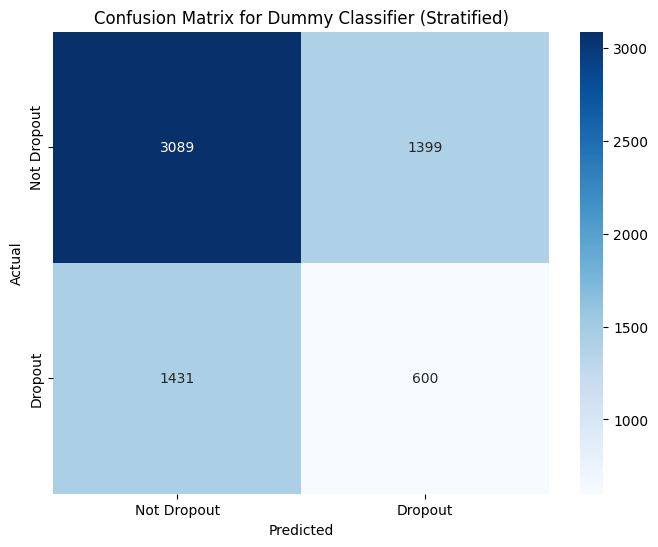

<Figure size 800x600 with 0 Axes>

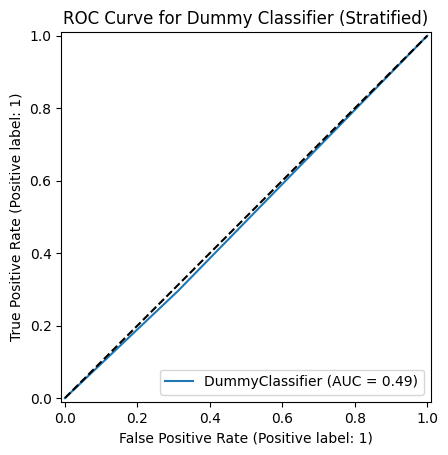

In [ ]:
# Plot Confusion Matrix for Dummy Classifier
cm_dummy = confusion_matrix(y_test_dropout, y_pred_dummy)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_dummy, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Not Dropout', 'Dropout'],
    yticklabels=['Not Dropout', 'Dropout']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Dummy Classifier (Stratified)')
plt.show()

# Plot ROC Curve for Dummy Classifier
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(dummy_clf, X_test_dropout, y_test_dropout)
plt.title('ROC Curve for Dummy Classifier (Stratified)')
plt.plot([0, 1], [0, 1], 'k--')  # Random baseline
plt.show()


In [ ]:
import matplotlib.pyplot as plt
from xgboost import plot_tree

# To visualize a single tree from the XGBoost model
# We'll plot the first tree (index=0) as an example.
# You can choose any tree index up to n_estimators-1.

fig, ax = plt.subplots(figsize=(20, 20))  # Adjust figure size for better readability
plot_tree(xgb_model, num_trees=0, ax=ax)
plt.title('First Decision Tree from XGBoost Model', fontsize=20)
plt.show()


residual plot